# One-head nanoGPT optimizer comparison

This notebook compares the completed **SGD + Nesterov**, **AdamW**, and **Muon + auxiliary AdamW** baselines under one matched one-block/one-head FineWeb-Edu protocol.

All epoch trajectories show individual runs, the across-seed mean, and a two-sided **95% Student-t** confidence interval. It compares `train_accuracy`, `test_accuracy`, `train_loss`, `test_loss`, perplexity, fixed-continuation BLEU, layer `alpha`, `ERG_gap`, and direct `num_traps`.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd / "baseline" / "nanogpt_one_head"]
EXPERIMENT_ROOT = next(
    (path for path in candidates if (path / "configs" / "reference.yaml").is_file()),
    None,
)
if EXPERIMENT_ROOT is None:
    raise FileNotFoundError("Run from baseline/nanogpt_one_head or the repository root")
sys.path.insert(0, str(EXPERIMENT_ROOT / "src"))

from rg_nanogpt_one_head import (
    MATRIX_COLORS,
    OPTIMIZER_COLORS,
    SUPPORTED_OPTIMIZERS,
    canonical_seeds,
    final_test_summary,
    load_config,
    load_epoch_metrics,
    load_layer_metrics,
    load_spectral_summary,
    load_test_results,
    plot_epoch_metric,
    plot_layer_metric,
    plot_spectral_optimizer_summary,
    roots,
    run_status_table,
)

CONFIG = load_config(EXPERIMENT_ROOT / "configs" / "reference.yaml")
SEEDS = canonical_seeds(CONFIG)
OPTIMIZERS = SUPPORTED_OPTIMIZERS
PATHS = roots()
PATHS["plots"].mkdir(parents=True, exist_ok=True)
display(run_status_table(PATHS["results"], optimizers=OPTIMIZERS, seeds=SEEDS))
display(pd.DataFrame({"optimizer": list(OPTIMIZER_COLORS), "color": list(OPTIMIZER_COLORS.values())}))
display(pd.DataFrame({"matrix_type": list(MATRIX_COLORS), "color": list(MATRIX_COLORS.values())}))

,optimizer,optimizer_label,seed,complete,steps,final_test_loss,final_test_bleu,run_dir
0,sgd_momentum,SGD + Nesterov,1337,True,9766,6.795297,0.425370,/tmp/rg-nanogpt-one-head/results/sgd_momentum/...
1,sgd_momentum,SGD + Nesterov,2027,True,9766,6.657117,0.477541,/tmp/rg-nanogpt-one-head/results/sgd_momentum/...
2,sgd_momentum,SGD + Nesterov,4099,True,9766,6.654429,0.304693,/tmp/rg-nanogpt-one-head/results/sgd_momentum/...
3,adamw,AdamW,1337,True,9766,8.762741,0.162843,/tmp/rg-nanogpt-one-head/results/adamw/seed_1337
4,adamw,AdamW,2027,True,9766,6.078949,0.221845,/tmp/rg-nanogpt-one-head/results/adamw/seed_2027
5,adamw,AdamW,4099,True,9766,6.484722,0.206350,/tmp/rg-nanogpt-one-head/results/adamw/seed_4099
6,muon,Muon + auxiliary AdamW,1337,True,9766,6.879056,0.012082,/tmp/rg-nanogpt-one-head/results/muon/seed_1337
7,muon,Muon + auxiliary AdamW,2027,True,9766,6.066104,0.521815,/tmp/rg-nanogpt-one-head/results/muon/seed_2027
8,muon,Muon + auxiliary AdamW,4099,True,9766,6.449141,0.376546,/tmp/rg-nanogpt-one-head/results/muon/seed_4099


,optimizer,color
0,sgd_momentum,#0072B2
1,adamw,#D55E00
2,muon,#009E73


,matrix_type,color
0,W_Q,#0072B2
1,W_K,#E69F00
2,W_V,#009E73
3,W_O,#D55E00
4,W_MLP_IN,#CC79A7
5,W_MLP_OUT,#56B4E9


## Load the complete nine-run suite

This fails if any optimizer/seed run is incomplete. The test set is monitoring-only and was never used for optimizer updates, schedule selection, early stopping, or hyperparameter tuning.

In [2]:
epoch_metrics = load_epoch_metrics(PATHS["results"], optimizers=OPTIMIZERS, seeds=SEEDS)
layer_metrics = load_layer_metrics(PATHS["results"], optimizers=OPTIMIZERS, seeds=SEEDS)
spectral_summary = load_spectral_summary(PATHS["results"], optimizers=OPTIMIZERS, seeds=SEEDS)
test_results = load_test_results(PATHS["results"], optimizers=OPTIMIZERS, seeds=SEEDS)
display(epoch_metrics.sort_values(["optimizer", "seed", "nominal_epoch"]))

,step,tokens_seen,epoch,elapsed_sec,tokens_per_sec,primary_lr,auxiliary_lr,train_loss,train_perplexity,train_accuracy,...,update_norm_since_eval,update_to_weight_ratio,mps_current_allocated_mb,mps_driver_allocated_mb,nominal_epoch,checkpoint_path,test_monitoring_only,optimizer,optimizer_label,seed
27,0,0,0.000000,1.795283,0.000000,0.000000,NaN,10.849178,51491.805453,0.000107,...,0.000000,0.000000,25.416016,1114.078125,0.000,/tmp/rg-nanogpt-one-head/results/adamw/seed_13...,1,adamw,AdamW,1337
28,1221,10002432,0.125030,368.416147,27149.819811,0.000582,NaN,7.921423,2755.690022,0.039230,...,11.978876,0.084861,305.638428,2346.953125,0.125,/tmp/rg-nanogpt-one-head/results/adamw/seed_13...,1,adamw,AdamW,1337
29,2441,19996672,0.249958,736.677806,27144.393175,0.000525,NaN,6.502949,667.105891,0.133835,...,39.945966,0.119739,305.518799,2346.953125,0.250,/tmp/rg-nanogpt-one-head/results/adamw/seed_13...,1,adamw,AdamW,1337
30,3662,29999104,0.374989,1108.895649,27053.135283,0.000438,NaN,8.001103,2984.247683,0.039246,...,6.869674,0.021978,305.394775,2350.953125,0.375,/tmp/rg-nanogpt-one-head/results/adamw/seed_13...,1,adamw,AdamW,1337
31,4883,40001536,0.500019,1487.393486,26893.714664,0.000334,NaN,7.207628,1349.686885,0.088501,...,12.811803,0.039616,305.461670,2346.953125,0.500,/tmp/rg-nanogpt-one-head/results/adamw/seed_13...,1,adamw,AdamW,1337
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22,4883,40001536,0.500019,1469.381084,27223.391147,0.031413,NaN,6.931356,1023.881115,0.123184,...,0.907948,0.033073,275.664307,2350.968750,0.500,/tmp/rg-nanogpt-one-head/results/sgd_momentum/...,1,sgd_momentum,SGD + Nesterov,4099
23,6104,50003968,0.625050,1836.523823,27227.508499,0.021679,NaN,6.813375,909.936772,0.129578,...,0.729302,0.025738,275.664307,2346.968750,0.625,/tmp/rg-nanogpt-one-head/results/sgd_momentum/...,1,sgd_momentum,SGD + Nesterov,4099
24,7324,59998208,0.749978,2212.120331,27122.488392,0.013043,NaN,6.740085,845.632415,0.134125,...,0.505672,0.017432,275.848389,2346.968750,0.750,/tmp/rg-nanogpt-one-head/results/sgd_momentum/...,1,sgd_momentum,SGD + Nesterov,4099
25,8545,70000640,0.875008,2633.916419,26576.636789,0.007110,NaN,6.683245,798.906980,0.138382,...,0.273216,0.009273,275.848389,2350.968750,0.875,/tmp/rg-nanogpt-one-head/results/sgd_momentum/...,1,sgd_momentum,SGD + Nesterov,4099


## Task metrics by epoch

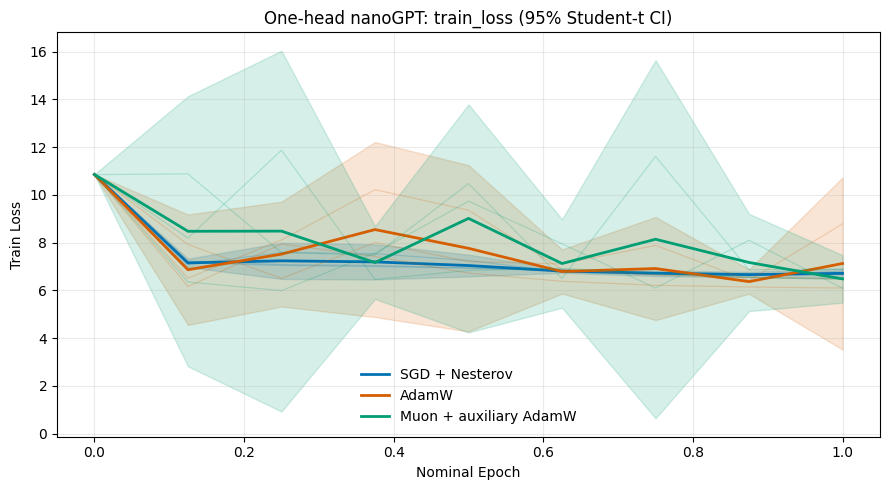

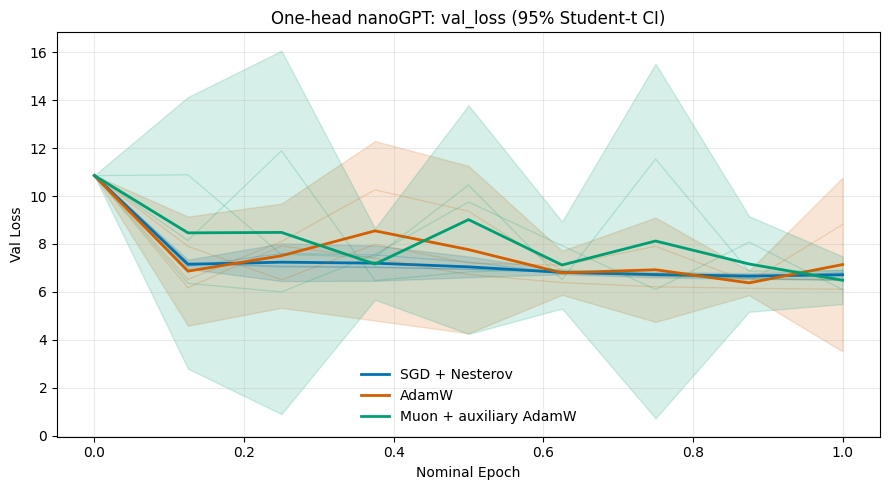

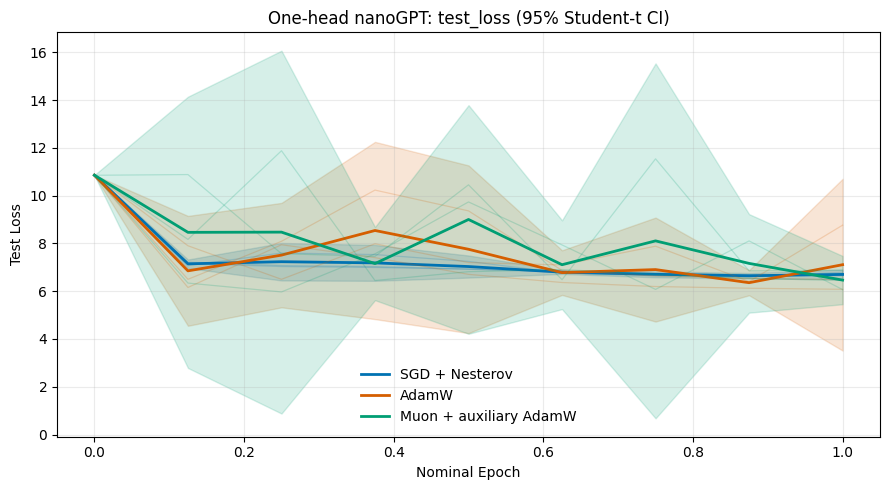

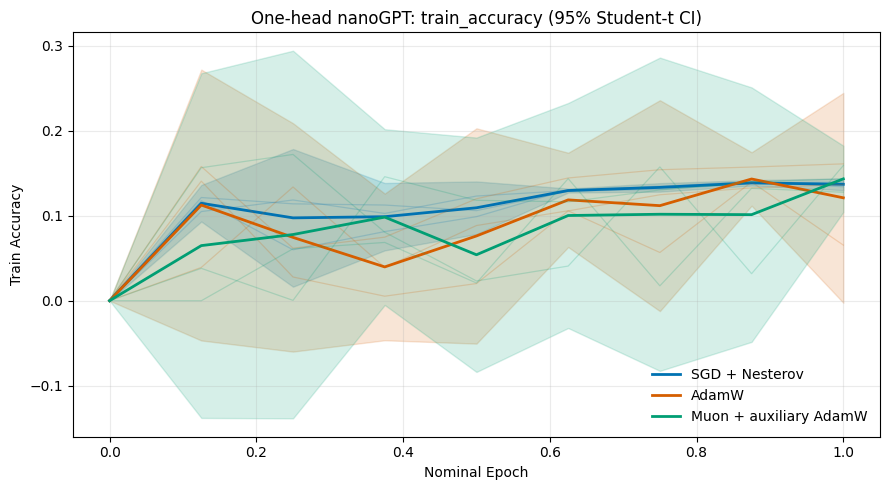

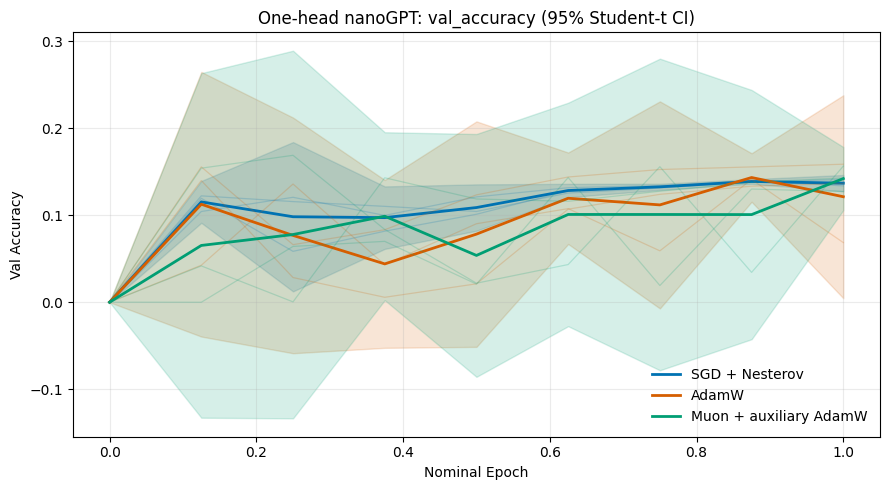

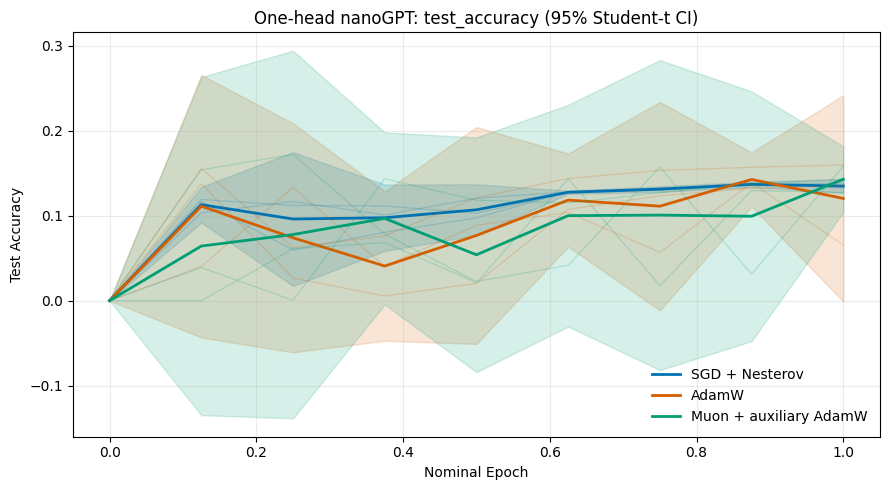

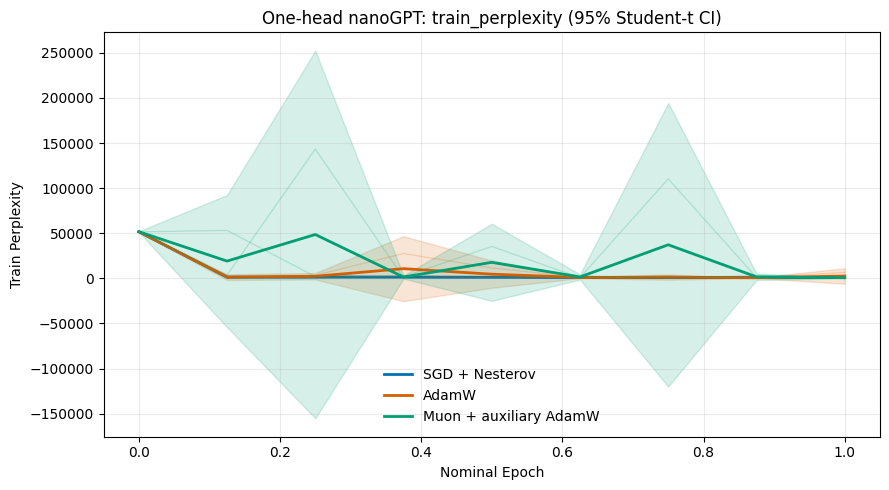

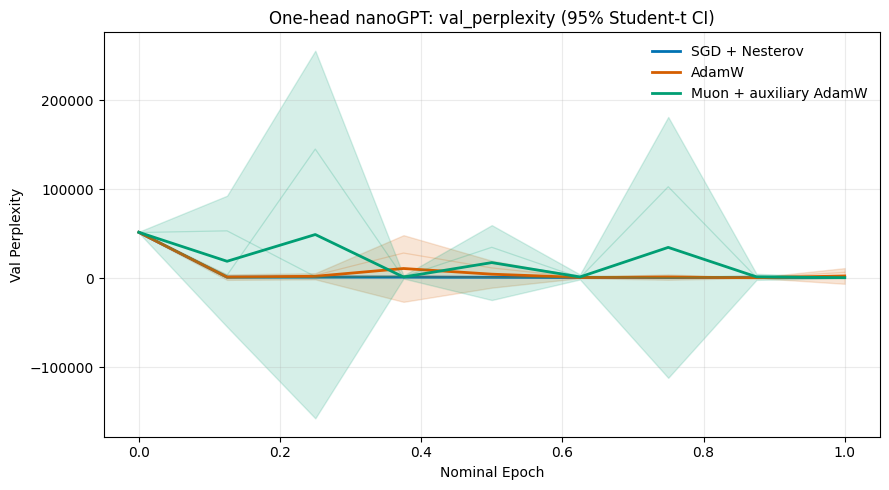

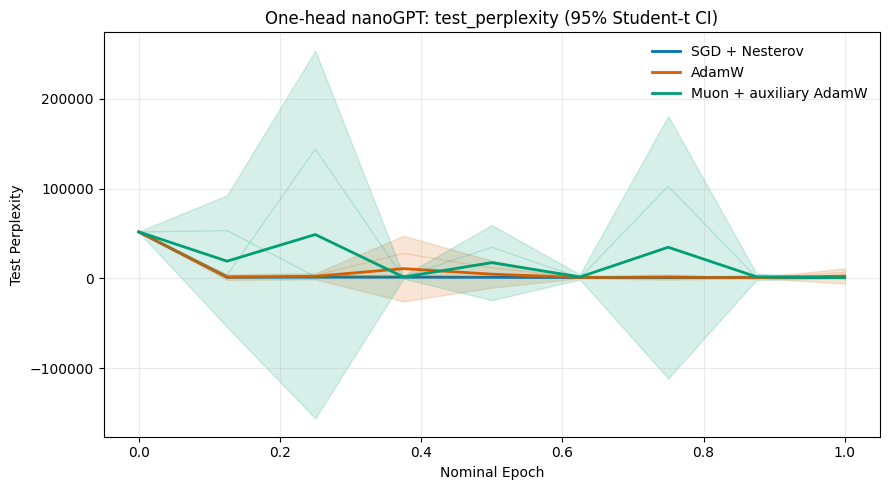

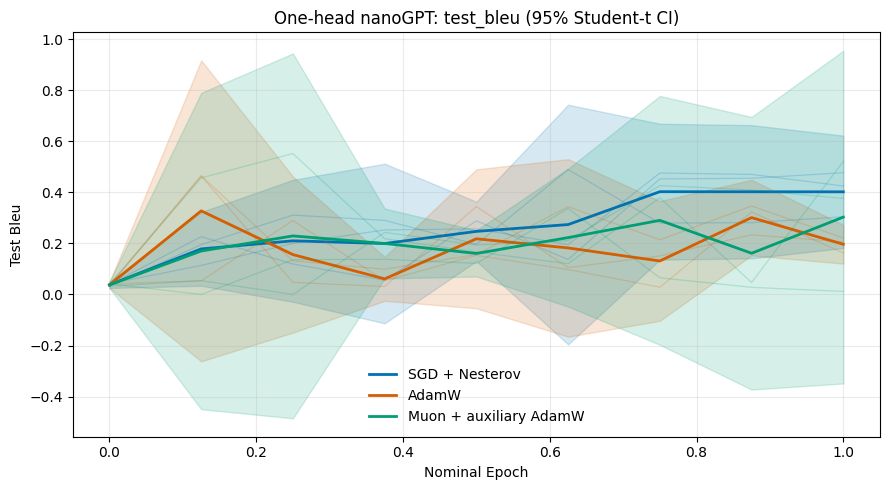

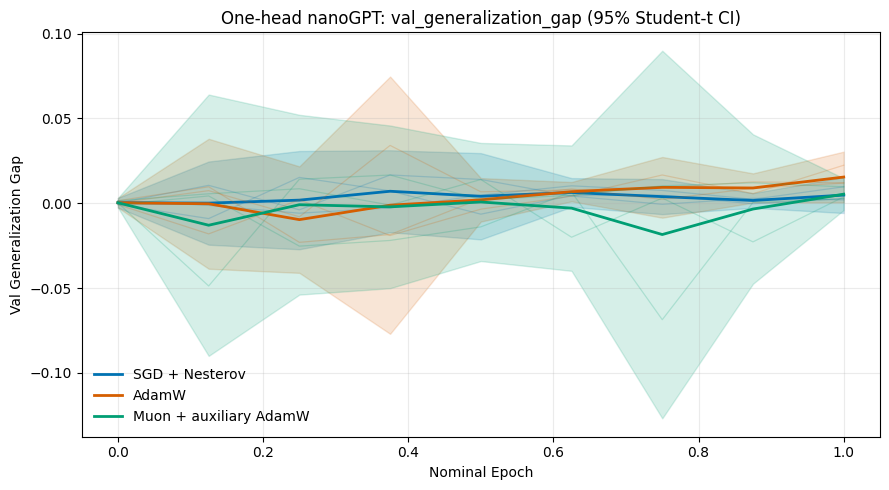

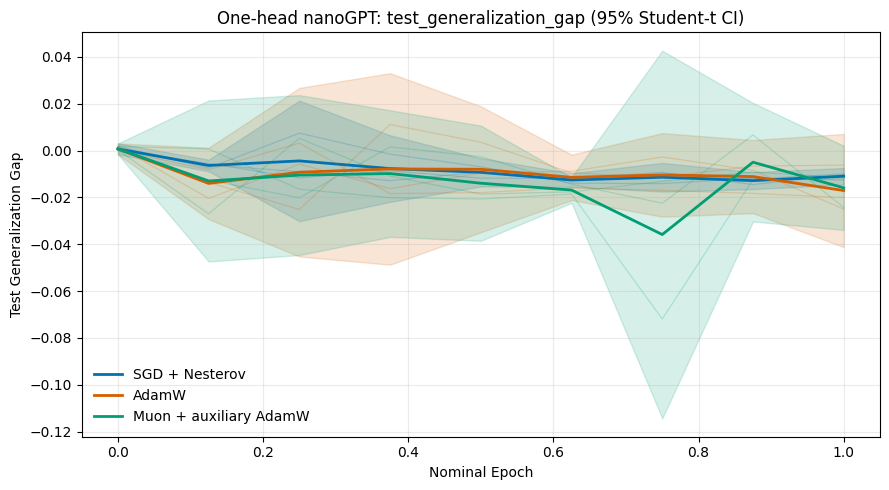

In [3]:
comparison_plot_dir = PATHS["plots"] / "comparison"
for metric in [
    "train_loss", "val_loss", "test_loss",
    "train_accuracy", "val_accuracy", "test_accuracy",
    "train_perplexity", "val_perplexity", "test_perplexity",
    "test_bleu", "val_generalization_gap", "test_generalization_gap",
]:
    plot_epoch_metric(
        epoch_metrics,
        metric=metric,
        optimizers=OPTIMIZERS,
        title=f"One-head nanoGPT: {metric} (95% Student-t CI)",
        output=comparison_plot_dir / f"{metric}.png",
    )
    plt.show()

## Optimizer-level WeightWatcher summaries

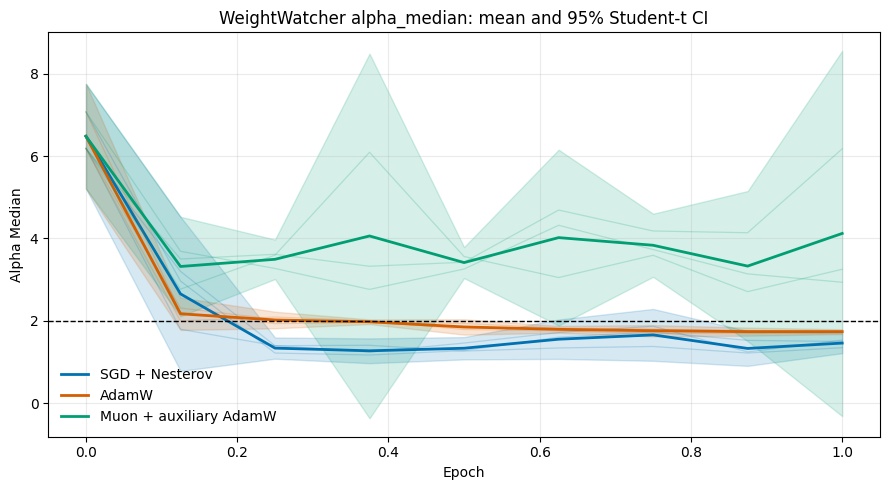

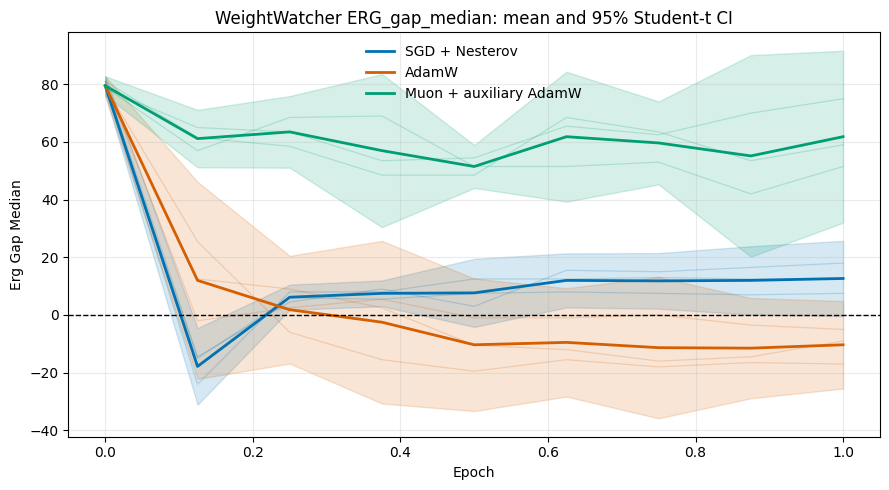

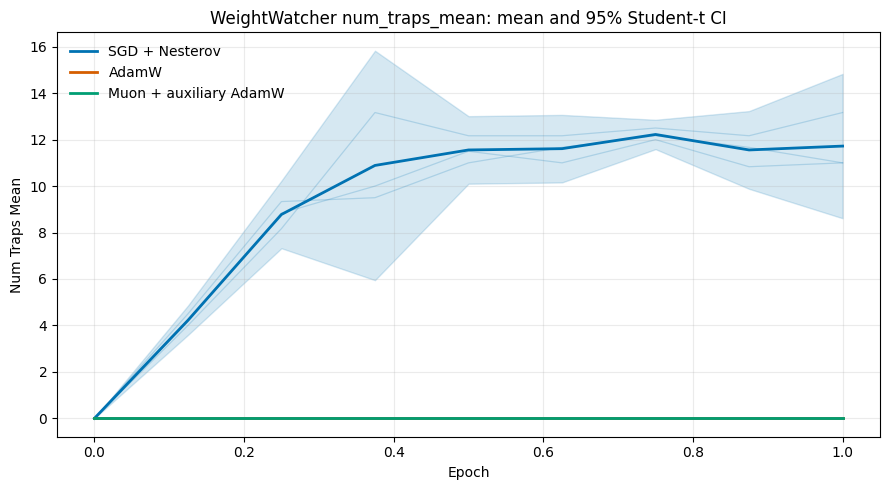

In [4]:
for metric in ["alpha_median", "ERG_gap_median", "num_traps_mean"]:
    plot_spectral_optimizer_summary(
        spectral_summary,
        metric=metric,
        optimizers=OPTIMIZERS,
        output=comparison_plot_dir / f"spectral_{metric}.png",
    )
    if metric == "alpha_median":
        plt.axhline(2.0, color="black", linestyle="--", linewidth=1.0)
    if metric == "ERG_gap_median":
        plt.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
    plt.show()

## Layer-resolved alpha, ERG gap, and correlation traps

The matrix color map is invariant across optimizers, so the same spectral object is visually comparable in every panel.

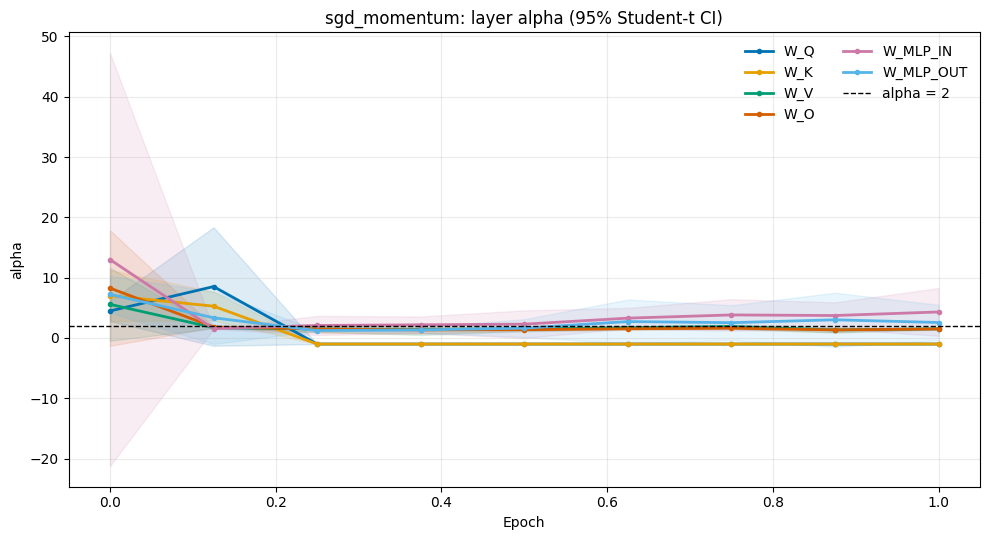

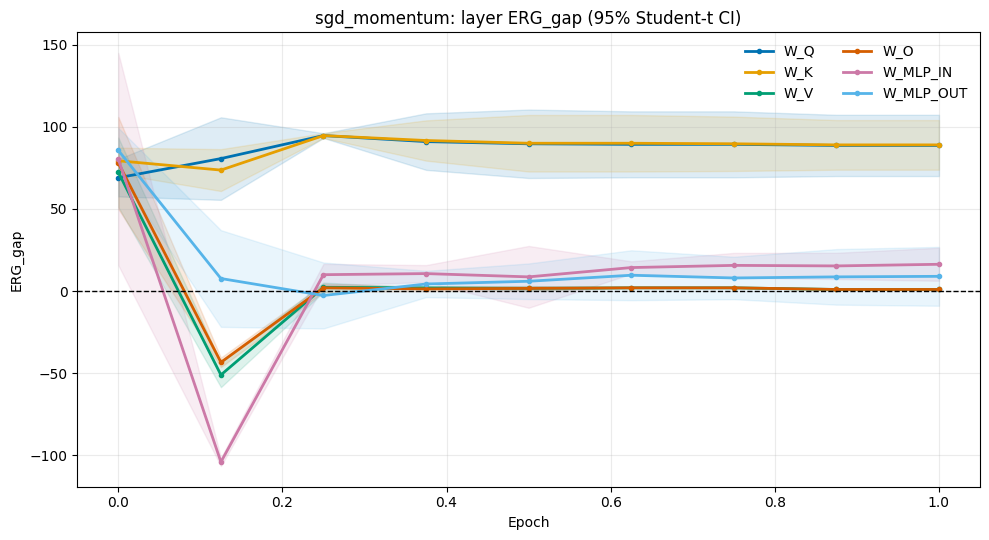

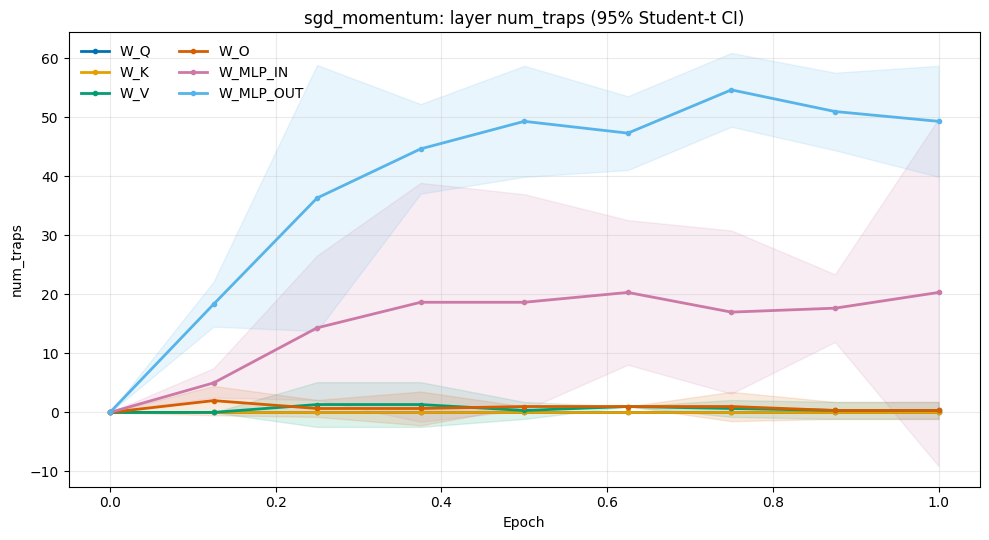

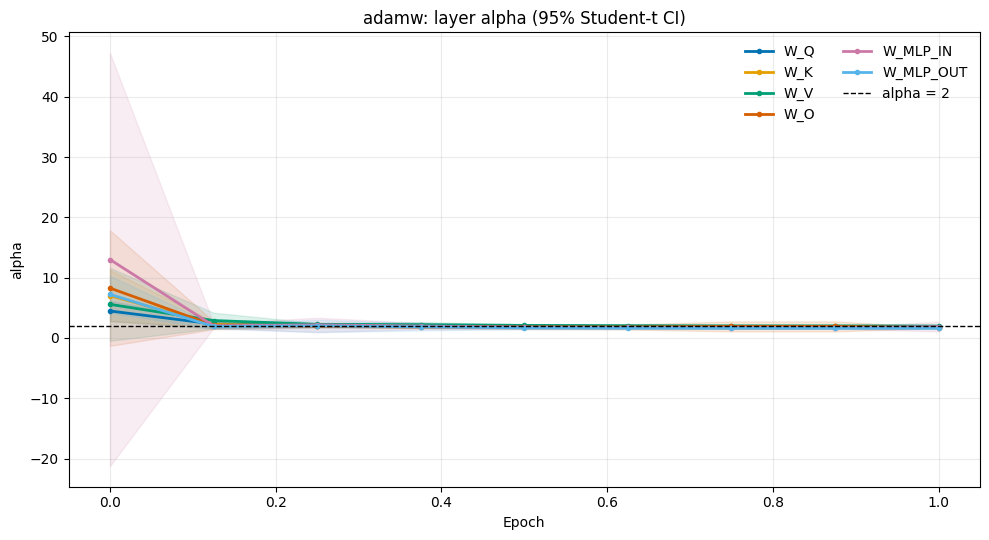

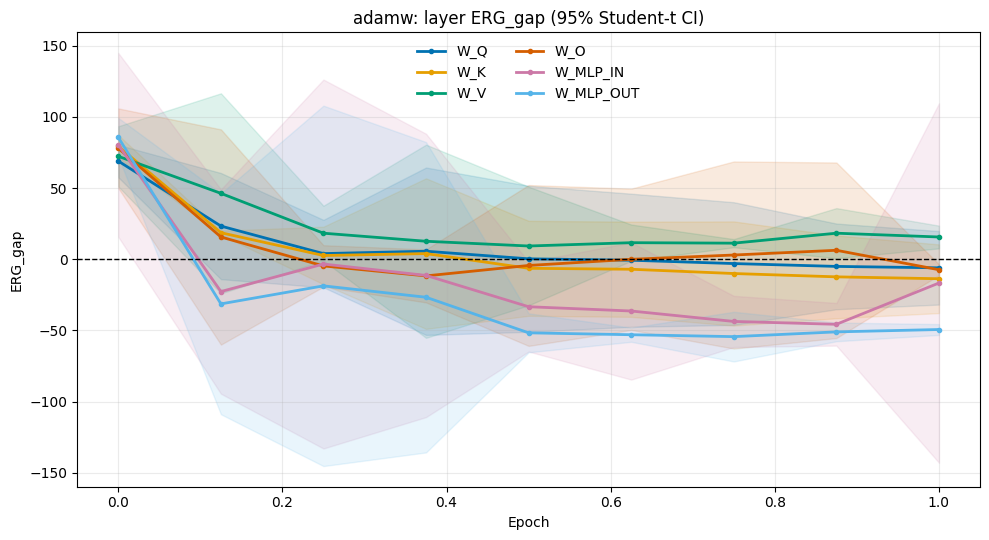

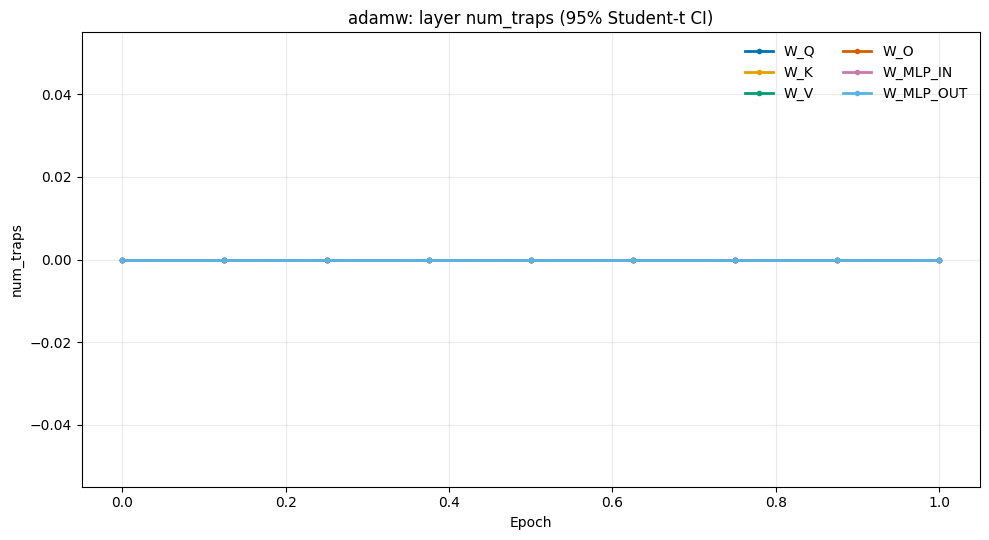

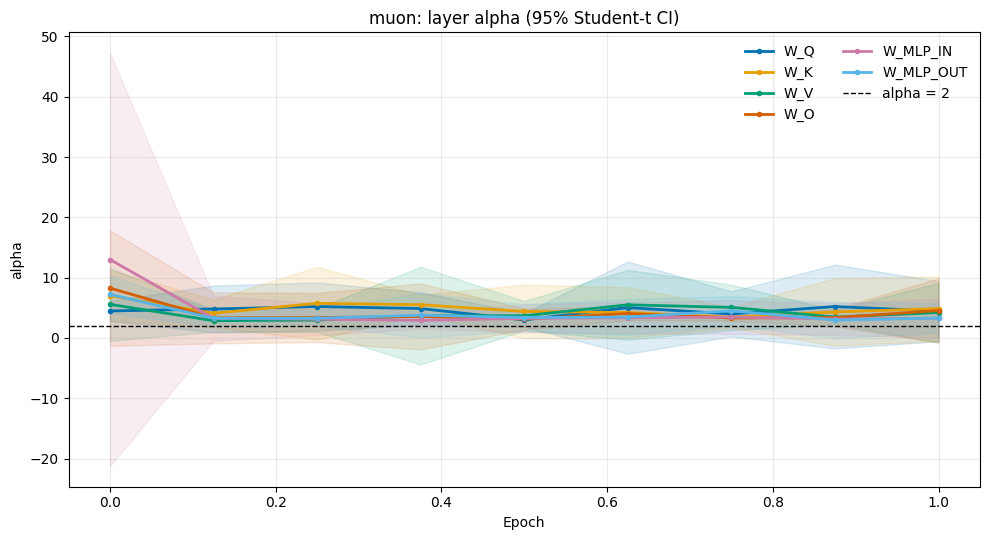

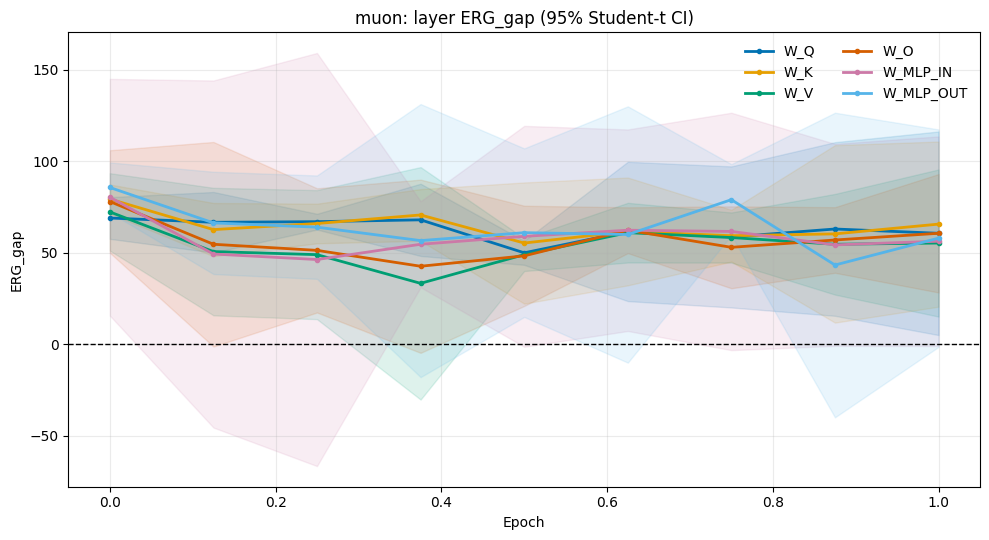

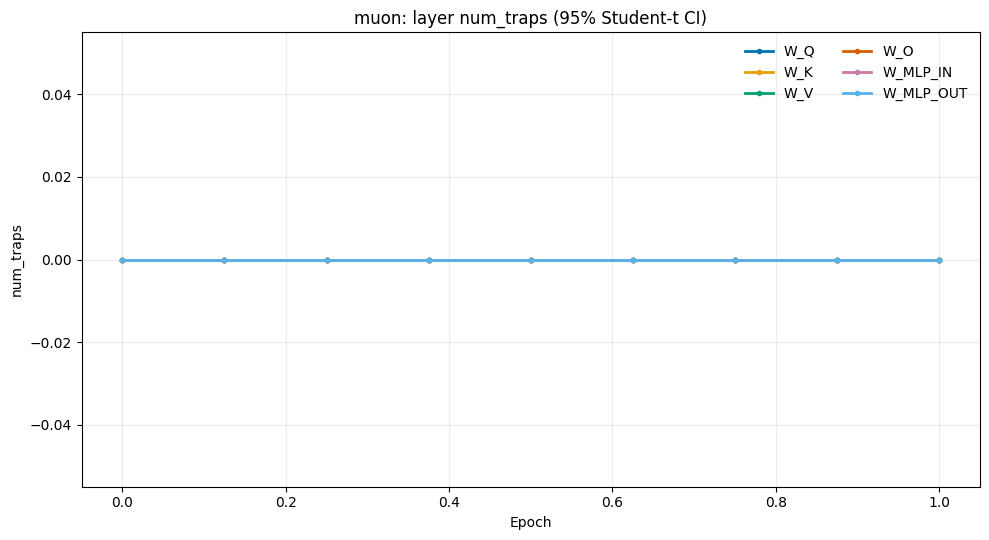

In [5]:
for optimizer in OPTIMIZERS:
    for metric in ["alpha", "ERG_gap", "num_traps"]:
        plot_layer_metric(
            layer_metrics,
            optimizer=optimizer,
            metric=metric,
            title=f"{optimizer}: layer {metric} (95% Student-t CI)",
            output=comparison_plot_dir / f"{optimizer}_layer_{metric}.png",
        )
        plt.show()

## Final and validation-selected test summaries

These tables report run-level 95% Student-t intervals across the three independent seeds.

In [6]:
summary = final_test_summary(test_results)
display(
    summary[
        [
            "optimizer_label", "checkpoint", "metric", "n", "mean", "sd",
            "ci95_half_width", "ci95_lower", "ci95_upper",
        ]
    ].sort_values(["checkpoint", "metric", "optimizer_label"])
)
summary.to_csv(comparison_plot_dir / "final_test_summary_95ci.csv", index=False)

,optimizer_label,checkpoint,metric,n,mean,sd,ci95_half_width,ci95_lower,ci95_upper
2,AdamW,final,test_accuracy,3,0.120407,0.048903,0.121482,-0.001075,0.241890
10,Muon + auxiliary AdamW,final,test_accuracy,3,0.143031,0.015565,0.038666,0.104364,0.181697
18,SGD + Nesterov,final,test_accuracy,3,0.135056,0.003207,0.007967,0.127088,0.143023
3,AdamW,final,test_bleu,3,0.197013,0.030589,0.075987,0.121026,0.273000
11,Muon + auxiliary AdamW,final,test_bleu,3,0.303481,0.262604,0.652345,-0.348864,0.955826
19,SGD + Nesterov,final,test_bleu,3,0.402535,0.088658,0.220238,0.182297,0.622773
0,AdamW,final,test_loss,3,7.108804,1.446649,3.593676,3.515128,10.702480
8,Muon + auxiliary AdamW,final,test_loss,3,6.464767,0.406701,1.010302,5.454465,7.475068
16,SGD + Nesterov,final,test_loss,3,6.702281,0.080566,0.200136,6.502145,6.902417
1,AdamW,final,test_perplexity,3,2494.412372,3376.839529,8388.534421,-5894.122049,10882.946793
